# Figure 1: A new self-initiated foraging task to study utility-driven modulations of vigor in running rats.

## setup and imports

In [160]:
import matplotlib.pyplot as plt
import fnmatch
import numpy as np
import glob
from scipy.ndimage import gaussian_filter as smooth

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *

plt.style.use('./Figures/paper.mplstyle')

In [161]:
# Define folder with data
root = "/home/thomas/Desktop/ALLDATA"

print("Path to data is: %s"%root)
print(f'Found {len(glob.glob(root+"/*"))} rats in the data folder')

Path to data is: /home/thomas/Desktop/ALLDATA
Found 34 rats in the data folder


### plot colors and markers for rats

In [162]:
# INTACT RATS
animalList = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
            'RatF32', 'RatF33', 'RatM31', 'RatM32', 'RatF42', 'RatM40', 'RatM43', 
            'RatM53', 'RatM54']

rat_markers = {}
m, f = 0, 0
male_palette = create_teal_palette(num_shades=len([x for x in animalList if 'M' in x]))
female_palette = create_blue_violet_palette(num_shades=len([x for x in animalList if 'F' in x]), start_intensity=80)

for index, animal in enumerate(animalList):
    print(f'Loading data for {animal}')
    # define marker and color for each rat, used in plots
    if fnmatch.fnmatch(animal, 'RatF*'):
        rat_markers[animal]=[female_palette[f], 'o', ]
        f += 1
    elif fnmatch.fnmatch(animal, 'RatM*'):
        rat_markers[animal]=[male_palette[m], 'o', ]
        m += 1
    elif fnmatch.fnmatch(animal, 'Rat00*'):
        rat_markers[animal]=[(0.0, 0.0, 0.0), "$\u2426$",]
    else:
        print("error, this is not a rat you got here")

# Define the example session to be shown
animal='RatM00'
session='RatM00_2021_07_22_16_13_03'

Loading data for RatF00
Loading data for RatF01
Loading data for RatF02
Loading data for RatM00
Loading data for RatM01
Loading data for RatM02
Loading data for RatF32
Loading data for RatF33
Loading data for RatM31
Loading data for RatM32
Loading data for RatF42
Loading data for RatM40
Loading data for RatM43
Loading data for RatM53
Loading data for RatM54


In [163]:
def make_mock_data(initial_value=1.0, slope=1.0, reward_effect=1.0, block=300):
    idx = np.arange(3600)
    alt_component = np.where((idx // block) % 2, reward_effect, 0)
    y = initial_value + slope * idx + alt_component
    smoothed_y = smooth(y, sigma=10)
    return smoothed_y

# 1A task rule schematic

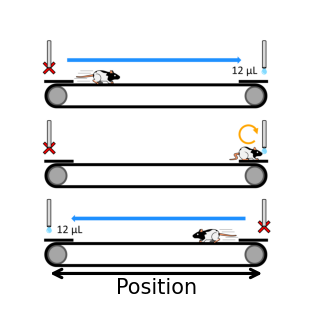

In [164]:
def Figure1A(ax=None, path=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    if path is None:
        path = "Figures/1A.png"

    try:
        img = plt.imread(path)
        ax.imshow(img)
    except FileNotFoundError:
        print("Image not found")
    ax.axis("off")

    ax.annotate(text='', xy=(150, 3150), xytext=(3100, 3150), arrowprops=dict(arrowstyle='<->', lw=0.75, color='k'), fontsize=5, zorder=5)
    
    ax.annotate(text='Position', xy=(0, 0), xytext=((150+3100)/2, 3200), ha='center', va='top', xycoords='data', fontsize=5, zorder=5)


fig, ax = plt.subplots(1, 1, figsize=(1, 1))
Figure1A(ax=ax)

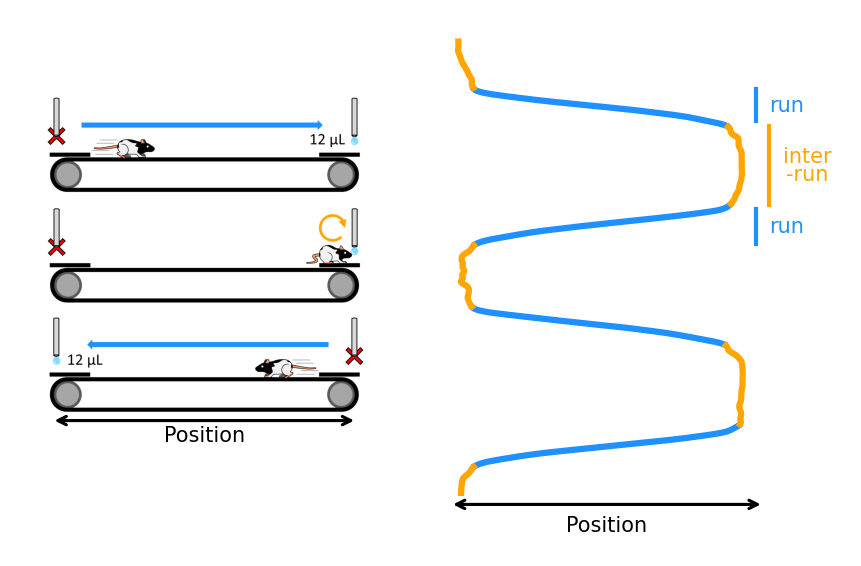

In [165]:
def Figure1Abis(root, 
            animal='RatM00', session='RatM00_2021_07_22_16_13_03',
            ax=None):
    '''
    read position file and plot animal trajectory
    '''
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    time = read_csv_pandas((root+os.sep+animal+os.sep+"Experiments"+os.sep + session + os.sep+session+".position"), Col=[3])[:90000]
    pos  = read_csv_pandas((root+os.sep+animal+os.sep+"Experiments"+os.sep + session + os.sep+session+".position"), Col=[4])[:90000]/11
    mask = stitch([get_from_pickle(root, animal, session, name="mask.p")])[0]   
    pos = smooth(pos.astype('float32'), 2)

    running_Xs = [val[0] if val[1] == True else None for val in [[i, j] for i, j in zip(pos, mask)]]
    idle_Xs = [val[0] if val[1] == False else None for val in [[i, j] for i, j in zip(pos, mask)]]
    start = int(3245.5*25)
    end = int(3265*25)
    running_Xs = running_Xs[start:end]
    idle_Xs = idle_Xs[start:end]
    time = time[start:end]
    


    ax.plot(running_Xs, time, label="run", color="dodgerblue", lw=1.5)
    ax.plot(idle_Xs, time, label="wait", color="orange", lw=1.5)

    time_run_1 = np.arange(3247.56, 3248.96, 0.04)
    time_run_2 = np.arange(3252.76, 3254.28, 0.04)
    time_inter_run = np.arange(3249.16, 3252.56, 0.04)

    ax.plot(np.ones(len(time_run_1))*115, time_run_1, color='dodgerblue', lw=1)
    ax.plot(np.ones(len(time_run_2))*115, time_run_2, color='dodgerblue', lw=1)
    ax.plot(np.ones(len(time_inter_run))*120, time_inter_run, color='orange', lw=1)

    ax.text(125, (3249.16+3252.56)/2, 'inter\n-run', ha="left", va="center", size=5, color='orange', linespacing=0.85, multialignment='center')
    ax.text(120, (3247.56+3248.96)/2, 'run', ha="left", va="center", size=5, color='dodgerblue')
    ax.text(120, (3252.76+3254.28)/2, 'run', ha="left", va="center", size=5, color='dodgerblue')


    ax.annotate(text='', xy=(.5, 3265.5), xytext=(120, 3265.5),
                arrowprops=dict(arrowstyle='<->', lw=0.75, color='k'), fontsize=5, zorder=5)
    
    ax.annotate(text='Position', xy=(.5, 3265.5), xytext=(120.5/2, 3266), 
                ha='center', va='top', xycoords='data', fontsize=5, zorder=5)

    ax.set_ylim(3245, 3266)
    ax.set_xlim(0, 140)
    ax.invert_yaxis()

    ax.axis('off')



fig, (img, zoom) = plt.subplots(1, 2, figsize = (cm2inch(7), cm2inch(4.5)))
Figure1A(ax=img)
Figure1Abis(ax=zoom, root=root)

# 1B Example session

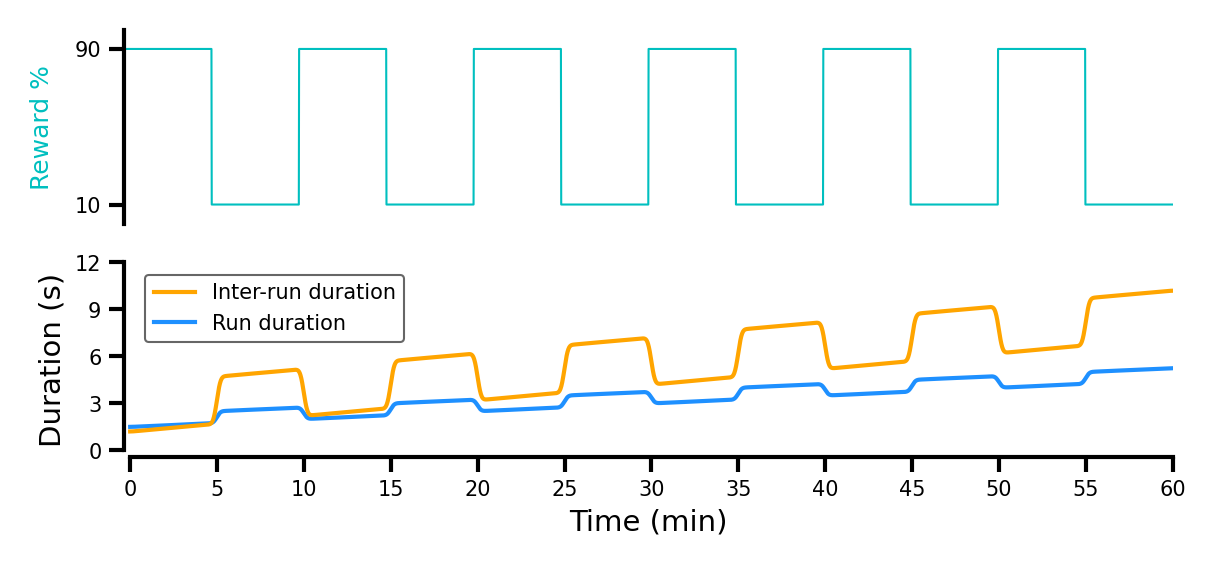

In [166]:

def Figure1B(ax=None):
    '''
    Prediction effect of time and reward probability on run and idle durations
    '''
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize = (cm2inch(10), cm2inch(4.5)))

    x = np.arange(0, 3600, 1)
    mock_runs = make_mock_data(initial_value=1.5, slope=3/3600, reward_effect=.75)
    mock_idle = make_mock_data(initial_value=1.2, slope=6/3600, reward_effect=3)

    ax.plot(x, mock_runs, color='dodgerblue', label='Run duration')
    ax.plot(x, mock_idle, color='orange', label='Inter-run duration')


    ax.set_xlim(0, 3600)
    ax.set_ylim(0, 12)
    ax.set_xticks(np.arange(0, 3601, 300))
    ax.set_xticklabels(np.arange(0, 61, 5))
    ax.set_yticks(np.arange(0, 13, 3))
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Duration (s)")
    
    handles, labels = ax.get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique[::-1]), loc='upper left', bbox_to_anchor=(0.01, 0.99), frameon=True, fontsize=5, markerscale=1, edgecolor='k', facecolor='w').get_frame().set_linewidth(.5)
    space_axes(ax, x_ratio_right=0, x_ratio_left=1/180)


def Figure1Bbis(root, 
            animal='RatM00', session='RatM00_2021_07_22_16_13_03', 
            ax=None):

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    params = get_from_pickle(root, animal, session, name="params.p")
    seq = get_from_pickle(root, animal, session, name="sequence.p")

    time = np.arange(0, 3600, 1)
    rewardProba = np.ones(3600)

    for t in range(0, len(time)):
        for i in range(0, len(params['blocks'])):
            if time[t] in range(params['blocks'][i][0], params['blocks'][i][1]):
                rewardProba[t] *= params['rewardProbaBlock'][i]

    ax.plot(time, rewardProba, color='c', lw=.5)

    ax.set_xlim(0, 3600)
    ax.set_ylim(0, 100)
    ax.set_yticks([10, 90])
    ax.set_yticklabels(["10", "90"])
    ax.set_ylabel("Reward %", labelpad=5, fontsize=6, color='c')
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)


fig, axs = plt.subplots(2, 1, figsize = (cm2inch(10), cm2inch(4.5)))
Figure1B(ax=axs[1])
Figure1Bbis(ax=axs[0], root=root)

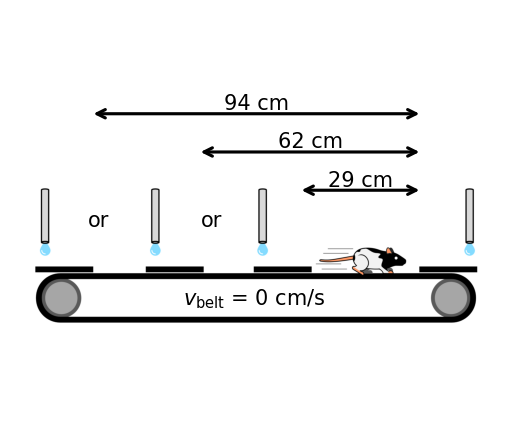

In [167]:
def Figure1C(ax=None, path=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    if path is None:
        path = "Figures/4Arun.png"

    img = plt.imread(path)
    img = img[300:2600, 150:3075]

    # add 300 above the image so same size as the other image
    img = np.concatenate((np.ones((300, img.shape[1], 3), dtype=np.uint8), img), axis=0)
    ax.imshow(img)
    ax.axis("off")
    ax.text(s=r'$v_{\mathrm{belt}}$ = 0 cm/s', x=img.shape[1]/2, y=1760, ha="center", va="center", fontsize=5)
    ax.text(s='or', x=450, y=1250, ha="center", va="center", fontsize=5)
    ax.text(s='or', x=1185, y=1250, ha="center", va="center", fontsize=5)

    ax.annotate(text='', xy=(1720, 1050), xytext=(2600, 1050), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    ax.annotate(text='', xy=(1060, 800), xytext=(2600, 800), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    ax.annotate(text='', xy=(360, 550), xytext=(2600, 550), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    
    ax.annotate(text='29 cm', xy=(0, 0), xytext=((1720+2600)/2, 1050), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)
    ax.annotate(text='62 cm', xy=(0, 0), xytext=((1060+2600)/2, 800), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)
    ax.annotate(text='94 cm', xy=(0, 0), xytext=((360+2600)/2, 550), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)

fig, ax = plt.subplots(1, 1, figsize=(cm2inch(4), cm2inch(4)))
Figure1C(ax=ax)

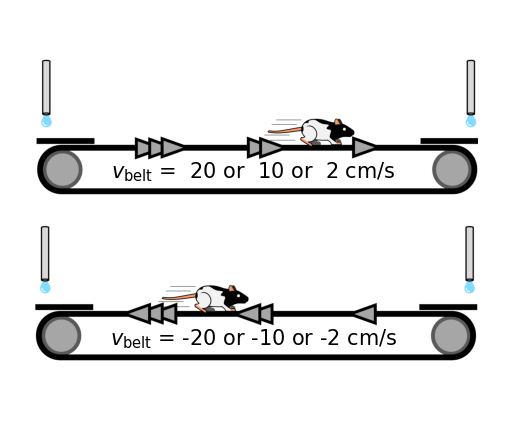

In [168]:
def Figure1E(ax=None, path=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    if path is None:
        path = "Figures/4Drun.png"

    img = plt.imread(path)
    img = img[:, 150:3075]
    ax.imshow(img)
    ax.axis("off")
    ax.text(s=r'$v_{\mathrm{belt}}$ =  20 or  10 or  2 cm/s', x=img.shape[1]/2, y=930, ha="center", va="center", fontsize=5)
    ax.text(s=r'$v_{\mathrm{belt}}$ = -20 or -10 or -2 cm/s', x=img.shape[1]/2, y=2020, ha="center", va="center", fontsize=5)

fig, ax = plt.subplots(1, 1, figsize=(cm2inch(4), cm2inch(4)))
Figure1E(ax=ax)

2.9952831266760085 3.995283126676008


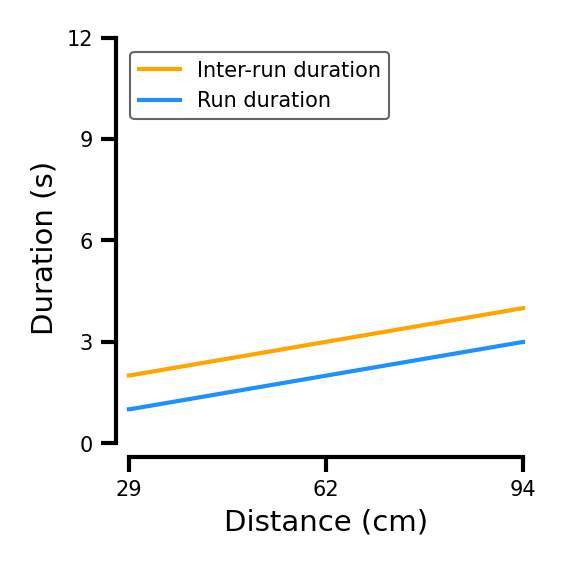

In [169]:

def Figure1D(ax=None):
    '''
    Prediction effect of time and reward probability on run and idle durations
    '''
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize = (cm2inch(10), cm2inch(4.5)))




    x = np.arange(0, 3600, 1)
    mock_runs = make_mock_data(initial_value=1, slope=2/3600, reward_effect=0)
    mock_idle = make_mock_data(initial_value=2, slope=2/3600, reward_effect=0)
    print(mock_runs[-1], mock_idle[-1])

    ax.plot(x, mock_runs, color='dodgerblue', label='Run duration')
    ax.plot(x, mock_idle, color='orange', label='Inter-run duration')


    ax.set_xlim(0, 3600)
    ax.set_ylim(0, 12)
    ax.set_xticks([0, 1800, 3600])
    ax.set_xticklabels(["29", "62", "94"])
    ax.set_yticks(np.arange(0, 13, 3))
    ax.set_xlabel("Distance (cm)")
    ax.set_ylabel("Duration (s)")
    
    handles, labels = ax.get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique[::-1]), loc='upper left', bbox_to_anchor=(0.01, 0.99), frameon=True, fontsize=5, markerscale=1, edgecolor='k', facecolor='w').get_frame().set_linewidth(.5)
    space_axes(ax)


fig, ax = plt.subplots(1, 1, figsize = (cm2inch(4.5), cm2inch(4.5)))
Figure1D(ax=ax)

3.0000000000000004 4.0


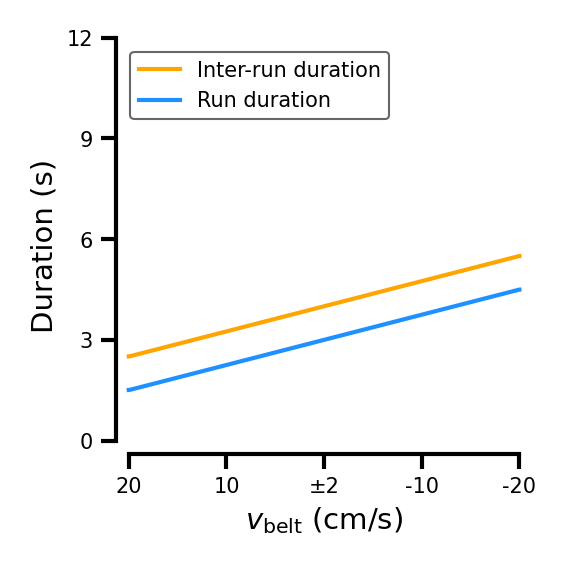

In [170]:

def Figure1F(ax=None):
    '''
    Prediction effect of time and reward probability on run and idle durations
    '''
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize = (cm2inch(10), cm2inch(4.5)))




    x = np.arange(0, 3600, 1)
    mock_runs = make_mock_data(initial_value=1.5, slope=3/3600, reward_effect=0)
    mock_idle = make_mock_data(initial_value=2.5, slope=3/3600, reward_effect=0)
    print(mock_runs[1800], mock_idle[1800])

    ax.plot(x, mock_runs, color='dodgerblue', label='Run duration')
    ax.plot(x, mock_idle, color='orange', label='Inter-run duration')


    ax.set_xlim(0, 3600)
    ax.set_ylim(0, 12)
    ax.set_xticks([0, 900, 1800, 2700, 3600])
    ax.set_xticklabels(["20", "10", "±2", "-10", "-20"])
    ax.set_yticks(np.arange(0, 13, 3))
    vbelt = r'$v_{\mathrm{belt}}$'
    ax.set_xlabel(f'{vbelt} (cm/s)')
    ax.set_ylabel("Duration (s)")
    
    handles, labels = ax.get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique[::-1]), loc='upper left', bbox_to_anchor=(0.01, 0.99), frameon=True, fontsize=5, markerscale=1, edgecolor='k', facecolor='w').get_frame().set_linewidth(.5)
    space_axes(ax)


fig, ax = plt.subplots(1, 1, figsize = (cm2inch(4.5), cm2inch(4.5)))
Figure1F(ax=ax)

# Figure 1: A new self-initiated foraging task to study utility-driven modulations of vigor in running rats.

2.9952831266760085 3.995283126676008
3.0000000000000004 4.0


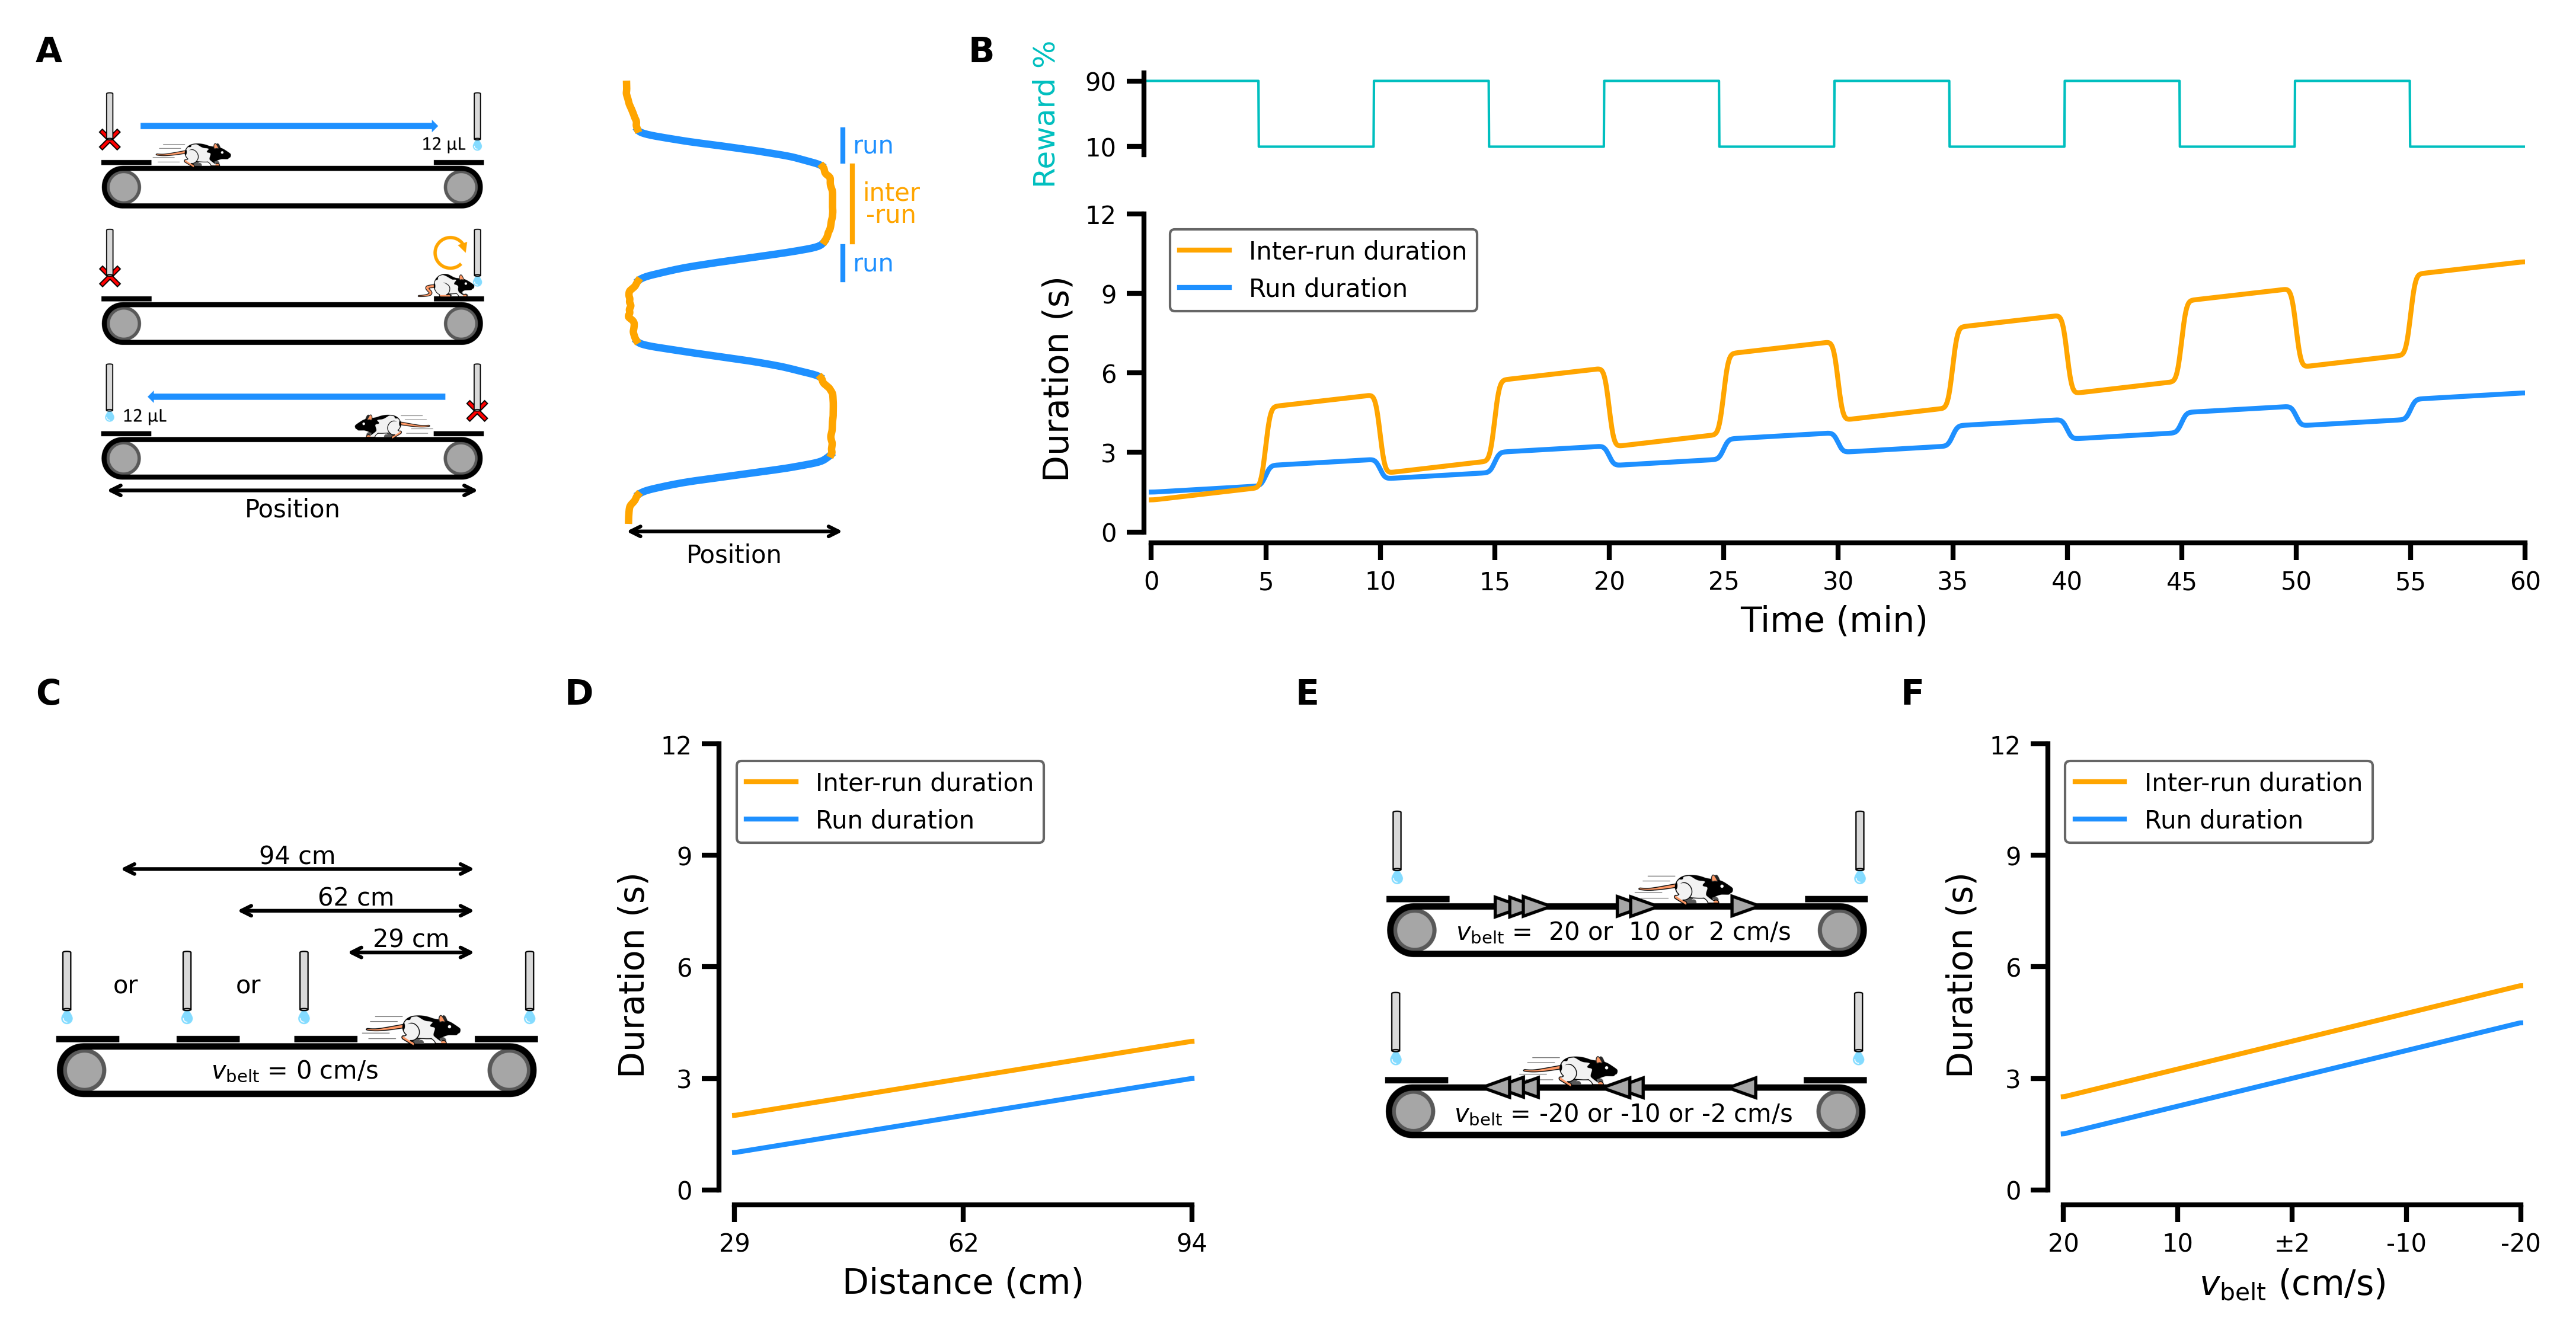

In [171]:
fig = plt.figure(figsize=(cm2inch(18), cm2inch(9)), 
               constrained_layout=True, facecolor='w', dpi=600)

gs0 = fig.add_gridspec(3, 1 , height_ratios=[9, 1, 9], hspace=0.15)

row1 = gs0[0].subgridspec(2, 4, height_ratios=[1, 4], width_ratios=[2, 1, 0.1, 5])
setup_schematic = plt.subplot(row1[:, 0])
zoom_track = plt.subplot(row1[:, 1])
raw_track_track = plt.subplot(row1[1, 3])
raw_track_proba = plt.subplot(row1[0, 3])

row2 = gs0[2].subgridspec(1, 7, wspace=1, width_ratios=[1, .01, 1, .2, 1, .01, 1])
distance_task = plt.subplot(row2[0, 0])
distance_task_prediction = plt.subplot(row2[0, 2])
vbelt_task = plt.subplot(row2[0, 4])
vbelt_task_prediction = plt.subplot(row2[0, 6])


Figure1A(ax=setup_schematic)
Figure1Abis(ax=zoom_track, root=root)
Figure1B(ax=raw_track_track)
Figure1Bbis(ax=raw_track_proba, root=root)

Figure1C(ax=distance_task)
Figure1D(ax=distance_task_prediction)
Figure1E(ax=vbelt_task)
Figure1F(ax=vbelt_task_prediction)


figuresLabels={"A":[0.00, .99], "B":[0.37, 0.99],
               "C":[0.00, .48], "D":[0.21, 0.48], "E":[0.50, 0.48], "F":[0.74, 0.48]}

for label,coordinates in sorted(figuresLabels.items()):
    fig.text(coordinates[0], coordinates[1], label, figure=fig, 
             weight='bold', fontsize=7, ha='left', va='bottom', color='k')

plt.savefig("./Figures_paper/Figure_1.pdf", facecolor='w', 
                edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)

plt.savefig("./Figures_paper/Figure_1.svg", facecolor='w', 
                edgecolor='none', bbox_inches='tight', format="svg", dpi=600)